In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline


In [11]:
df =pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


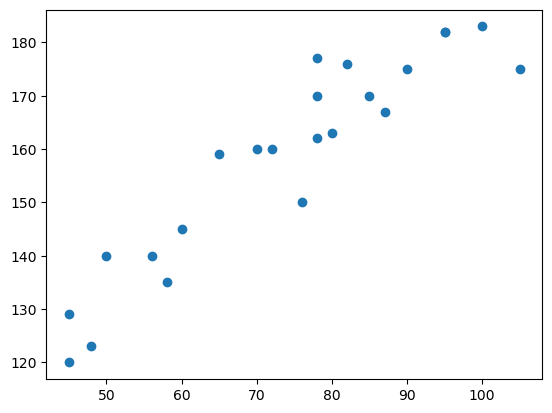

In [12]:
plt.scatter(df.Weight, df.Height)

1. Dataset
2. divide the features into independent and  dependent features
3. train test split
4. Stadardize the dataset Train independent data
5. train the model

In [14]:
# 2. divide the features into independent and  dependent features

X = df[['Weight']]
y = df.Height

In [15]:
# 3. train test split

from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test =  train_test_split(X,y, test_size=.2, random_state=42)

In [16]:
X_train.shape

(18, 1)

In [ ]:
# 4. Stadardize the dataset Train independent data

from sklearn.preprocessing import StandardScaler

scaler =  StandardScaler()

X_train = scaler.fit_transform(X_train) # fit compute the mean And Std and transform apply it in each datapoint

In [ ]:
X_test = scaler.transform(X_test) #  not use fit here  there may be data leakage issue

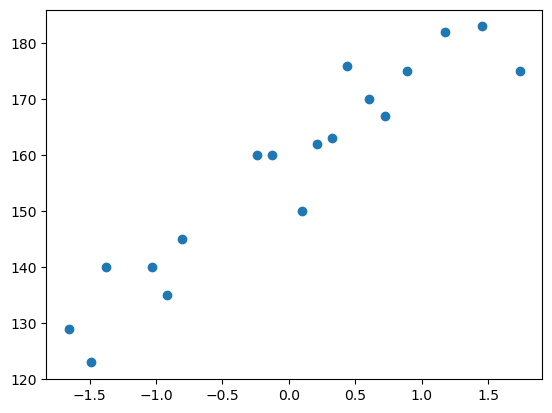

In [20]:
plt.scatter(X_train,y_train)

In [22]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

In [23]:
regressor.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("the slope or co-eff of weight is " ,regressor.coef_) # theta1
print("Intercept is " ,regressor.intercept_) # theta0

the slope or co-eff of weight is  [17.03440872]
Intercept is  157.5


y_pred_test = 157.5 + 17.03*(X_test)

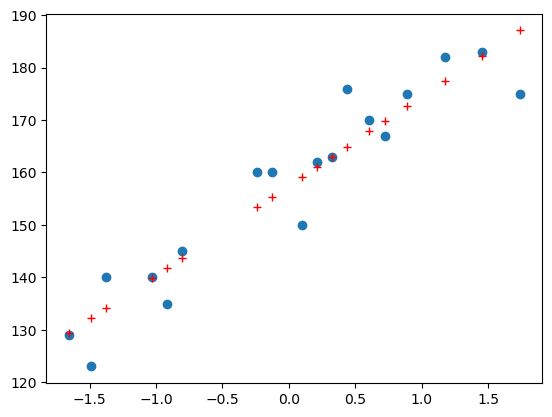

In [38]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),'r+')

In [41]:
y_test_pred = regressor.predict(X_test)

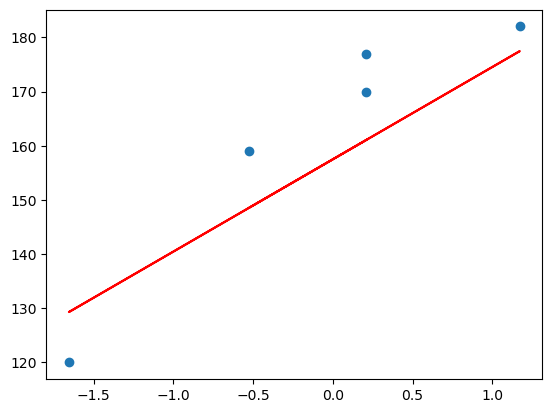

In [44]:
plt.scatter(X_test,y_test)
plt.plot(X_test,y_test_pred,'r')

In [48]:
y_test,y_test_pred

(15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64,
 array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]))

In [53]:
# Compute performance metrics

from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score


mse = mean_squared_error(y_test,y_test_pred)
mae = mean_absolute_error(y_test,y_test_pred)
rmse =  np.sqrt(mse)

print(mse)
print(mae)
print(rmse)


109.77592599051664
9.822657814519232
10.477400726827081


In [56]:
score = r2_score(y_test,y_test_pred)
print(score)

0.776986986042344


In [ ]:
# adjusted r square

1 - (1-score)*(len(y_test)-1) / (len(y_test) - X_test.shape[1] -1)

0.7026493147231252

In [58]:
# new datapoint

scaled_weight=scaler.transform([[80]])
scaled_weight

d:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [60]:
scaled_weight.shape

(1, 1)

In [59]:
regressor.predict([scaled_weight[0]])

array([163.01076266])

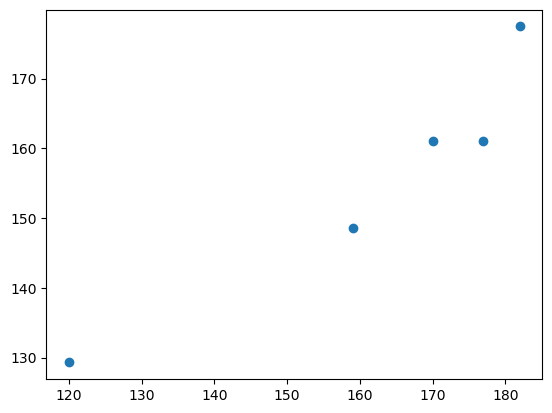

In [61]:
# assumptions 

## plot scatter plot for prediction vs real 
### if the point are linearly distributed the model is performing well

plt.scatter(y_test, y_test_pred)



In [64]:
# residuals
residuals = y_test- y_test_pred
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

C:\Users\User\AppData\Local\Temp\ipykernel_15128\1752274662.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde = True)


<Axes: xlabel='Height', ylabel='Density'>

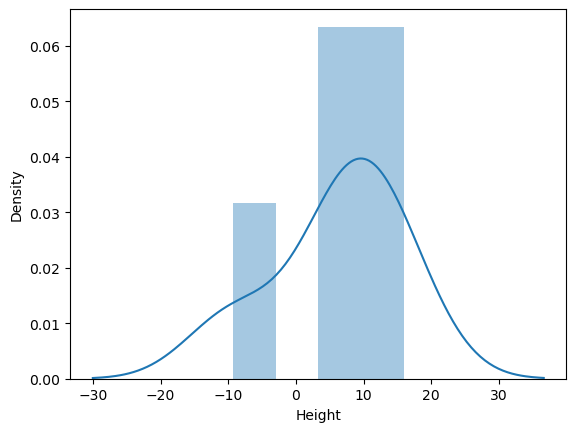

In [ ]:
# plot residuals

import seaborn as sns
sns.distplot(residuals,kde = True)

## if my residuals kernel density =plot is nearly normally distributed

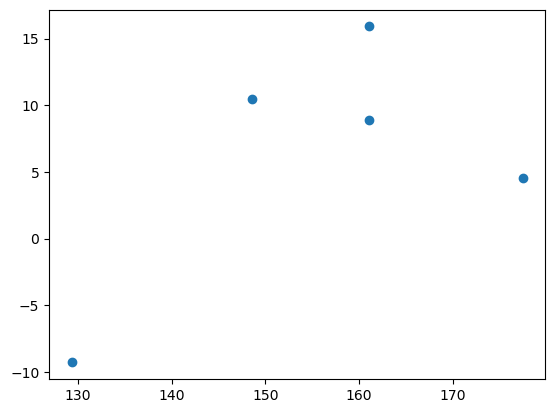

In [68]:
## if scatter plot with respect to prediction ansd residuals 
## uniform distribution 
# then the model is performing well

plt.scatter(y_test_pred,residuals)

